In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import os
from glob import glob
from collections import OrderedDict
import xarray as xr
import numpy as np

#import ncar_jobqueue
#from dask.distributed import Client

import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cftime

### Read in one year of ERA SST data so we can find the clipping region

In [3]:
sst_2025 = xr.Dataset()
path = '/gdex/data/d633000/e5.oper.an.sfc/2025'
#/gdex/data/d633000/e5.oper.an.sfc/202501/e5.oper.an.sfc.128_034_sstk.ll025sc.2025010100_2025013123.nc


files = []
for mon in range(1,13):
    mo2="{:02d}".format(mon)
    files.extend(sorted(glob(f'{path}{mo2}/e5.oper.an.sfc.128_034_sstk.ll025sc.??????????_??????????.nc')))

sst_2025 = xr.open_mfdataset(files, combine='by_coords')

In [4]:
sst_2025

<xarray.Dataset>
Dimensions:            (time: 8760, latitude: 721, longitude: 1440)
Coordinates:
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 0.0 0.25 0.5 ... 359.2 359.5 359.8
  * time               (time) datetime64[ns] 2025-01-01 ... 2025-12-31T23:00:00
Data variables:
    SSTK               (time, latitude, longitude) float32 dask.array<chunksize=(27, 139, 277), meta=np.ndarray>
    quantization_info  (time) |S1 b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    utc_date           (time) int32 dask.array<chunksize=(744,), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.9.2
    CONVERSION_PLATFORM:  Linux crhtc68 5.14.21-150400.24.46-default #1 SMP P...
    CONVERSION_DATE:      Tue 15 Apr 2025 08:09:50 PM MDT
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Tue Apr 15 20:10:00 2025: ncks -4 -L 1 --baa=0 --pp...
    NCO:                  netCDF Operators version 5.3.1 (Homepage = http://n...

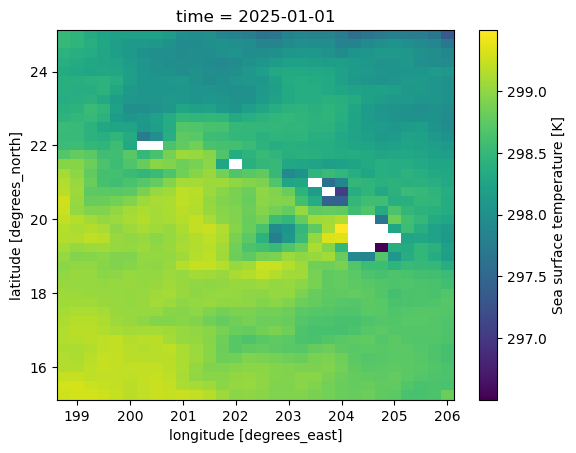

In [5]:
sst_2025.SSTK.isel(time=0, latitude=slice(260,300), longitude=slice(795,825)).plot()

### This box looks good, read in all the data, clipping it to this region, and converting hourly to daily data

In [6]:
ds = xr.Dataset()


for year in np.arange(1980,2024,1):
    y4 = "{:04d}".format(year)

    print(year)
    
    #sst_tmp = xr.Dataset()
    path = '/gdex/data/d633000/e5.oper.an.sfc/' + y4
    #/gdex/data/d633000/e5.oper.an.sfc/202501/e5.oper.an.sfc.128_034_sstk.ll025sc.2025010100_2025013123.nc


    files = []
    for mon in range(1,13):
        mo2="{:02d}".format(mon)
        files.extend(sorted(glob(f'{path}{mo2}/e5.oper.an.sfc.128_034_sstk.ll025sc.{y4}??????_{y4}??????.nc')))
    
    sst_tmp = xr.open_mfdataset(files, combine='by_coords')

    ## now clip it
    sst_tmp = sst_tmp.isel(latitude=slice(260,300), longitude=slice(795,825))


    # Resample from hourly to daily SST
    sst_daily = sst_tmp.resample(time='D').mean(dim='time')
    sst_daily = sst_daily.rename({'time':'valid_time', 'SSTK':'sst'})
    sst_daily = sst_daily.drop_vars('utc_date')
    #sst_daily['latitude'] = lats
    #sst_daily['longitude'] = lons

    # Convert from K to C
    sst_daily['sst'] = sst_daily['sst'] - 273.15

    if year==1980:    

        ds = sst_daily
    else:
        ds = xr.concat([ds,sst_daily],dim='valid_time')

1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [7]:
ds

<xarray.Dataset>
Dimensions:     (valid_time: 16071, latitude: 40, longitude: 30)
Coordinates:
  * latitude    (latitude) float64 25.0 24.75 24.5 24.25 ... 15.75 15.5 15.25
  * longitude   (longitude) float64 198.8 199.0 199.2 ... 205.5 205.8 206.0
  * valid_time  (valid_time) datetime64[ns] 1980-01-01 1980-01-02 ... 2023-12-31
Data variables:
    sst         (valid_time, latitude, longitude) float32 dask.array<chunksize=(2, 18, 30), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.6.1
    CONVERSION_PLATFORM:  Linux r1i1n20 3.12.62-60.64.8-default #1 SMP Tue Oc...
    CONVERSION_DATE:      Sun May 19 20:08:31 MDT 2019
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Sun May 19 20:08:46 2019: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 4.7.4 (http://nco.sf.net)

### Data read in and ready

In [23]:
ones = np.full((40,30),1,dtype=int)
ones = xr.DataArray(ones,dims=('latitude','longitude'))

In [24]:
#--- define region box around Kiholo region:
lon_min = 203.8
lon_max = 204.2
lat_min = 19.5
lat_max = 20

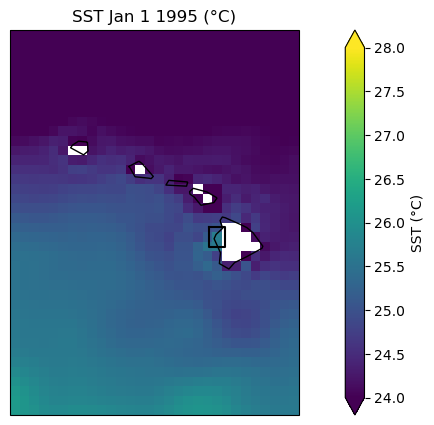

In [25]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
#ax.set_extent([lon_min-5, lon_max+2.8, lat_min-2, lat_max+2])
ax.set_title("SST Jan 1 1995 (°C)")
pc=ax.pcolormesh(ds.longitude, ds.latitude, ds.sst.isel(valid_time=0), cmap='viridis',
                 vmin=24,vmax=28,
                 transform=ccrs.PlateCarree())
lon_pts = [lon_min,lon_max,lon_max,lon_min,lon_min]
lat_pts = [lat_max,lat_max,lat_min,lat_min,lat_max]
ax.plot(lon_pts, lat_pts, color="black", linewidth=1.5,transform=ccrs.PlateCarree())

ax.coastlines('110m',linewidth=1)
cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='SST (°C)')

In [26]:
lats = ds.latitude
lons = ds.longitude

In [27]:
mask = ones.where(lats<lat_max).where(lats>lat_min).where(lons<lon_max).where(lons>lon_min)
mask = mask.where(ds.sst.isel(valid_time=0) > -10)

### Grid cell closest to Kiholo (PLEASE VERIFY, just an example)

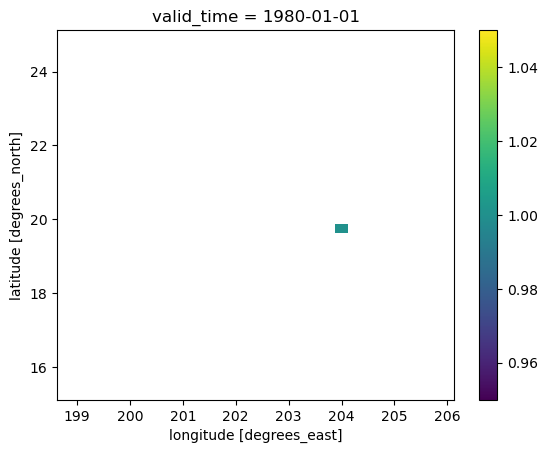

In [46]:
mask.plot()

### Find the coordinates of this gridcell

In [47]:
coords = np.argwhere(~np.isnan(mask.values))

coords

array([[21, 21]])

In [41]:
mask[21,21].values

array(1.)

In [48]:
masked_var = ds['sst'].where(mask==1)
masked_var[0,21,21].values

array(25.678986, dtype=float32)

### Make sure we grabbed the right gridcell

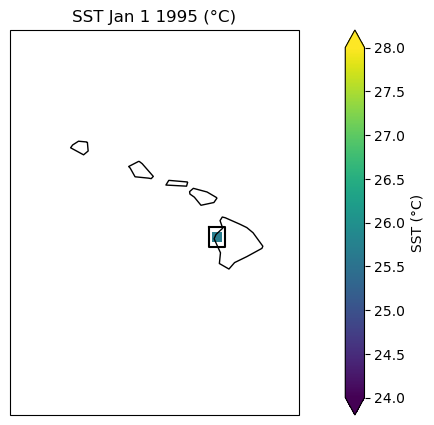

In [49]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
#ax.set_extent([lon_min-5, lon_max+2.8, lat_min-2, lat_max+2])
ax.set_title("SST Jan 1 1995 (°C)")
pc=ax.pcolormesh(ds.longitude, ds.latitude, masked_var.isel(valid_time=0), cmap='viridis',
                 vmin=24,vmax=28,
                 transform=ccrs.PlateCarree())
lon_pts = [lon_min,lon_max,lon_max,lon_min,lon_min]
lat_pts = [lat_max,lat_max,lat_min,lat_min,lat_max]
ax.plot(lon_pts, lat_pts, color="black", linewidth=1.5,transform=ccrs.PlateCarree())

ax.coastlines('110m',linewidth=1)
cbar1 = fig.colorbar(pc, ax=ax,extend='both',label='SST (°C)')

### Ok, looks good, now just grab this gridcell data (this takes ~20 minutes!!)

In [53]:
%%time

ts = xr.Dataset()
ts['sst'] = ds.sst[:,21,21]

ts = ts.load()

CPU times: user 4min 27s, sys: 7.55 s, total: 4min 35s
Wall time: 19min 31s


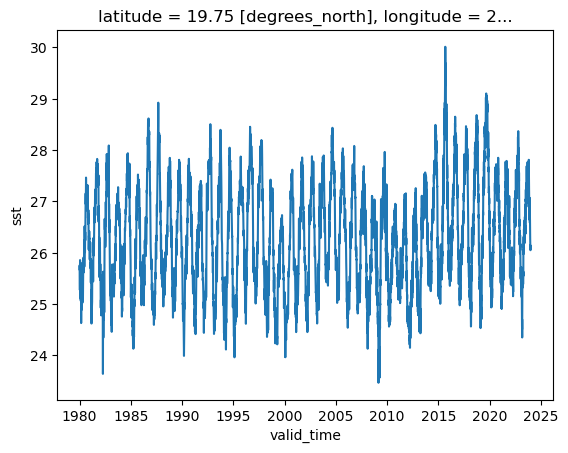

In [54]:
ts['sst'].plot()

### Write these daily SST timeseries out so we can read them into a coral bleaching notebook (this step also takes a long time)

In [56]:
path = '/glade/derecho/scratch/kristenk/bleaching_work'

### write out gridded data (just the Hawaii region), in case we want to make coral bleaching maps around Hawaii region
ds.to_netcdf(path + '/Hawaii_region_SST_ERA5.nc',mode='w')

In [57]:
### write out the timeseries for Kiholo
ts.to_netcdf(path + '/Kiholo_ERA5_SST_timeseries_daily.nc',mode='w')